# Sistema Financeiro e Crédito no Brasil (2015–2024)

**Projeto G1 — Tema 28** · Linguagem de Programação: Análise e Visualização de Dados com Python
**Aluno:** Rafael Murayama Barcelos

---

## Sumário
1. Introdução ao problema
2. Contextualização financeira
3. Explicação da base de dados
4. Leitura dos dados
5. Limpeza e preparação
6. Engenharia de atributos
7. Análise exploratória
8. KPIs
9. Gráficos e análises
10. Persistência em banco (SQLAlchemy + SQLite)
11. Interpretação dos resultados
12. Conclusão

## 1. Introdução ao problema

O crédito é um dos principais mecanismos de financiamento do consumo e do investimento. A forma como ele é
concedido — em quais regiões, para quais setores, em quais modalidades e a que custo — determina tanto o
potencial de crescimento econômico quanto o nível de risco assumido pelo sistema financeiro.

O objetivo deste notebook é **investigar padrões financeiros e de crédito no Brasil entre 2015 e 2024**, respondendo às
perguntas orientadoras do projeto:

1. Quais regiões apresentam maior volume de crédito?
2. Quais setores possuem maior inadimplência?
3. Houve crescimento do crédito ao longo do tempo?
4. Existe relação entre juros e inadimplência?
5. Quais modalidades financeiras apresentam maior risco?
6. Como o comportamento financeiro evoluiu?
7. Quais estados possuem maior concentração bancária?

Os resultados aqui obtidos alimentam o dashboard interativo desenvolvido em Streamlit (`app.py`).

## 2. Contextualização financeira

Alguns conceitos utilizados ao longo da análise:

| Conceito | Definição |
|---|---|
| **Volume de crédito** | Valor total concedido aos tomadores no período. |
| **Taxa de juros** | Custo do crédito para o tomador (% ao ano). Tende a refletir o risco percebido e a política monetária (Selic). |
| **Inadimplência** | Percentual da carteira com pagamentos em atraso. É o principal indicador de risco realizado. |
| **Risco de crédito** | Classificação *ex ante* da operação (Baixo, Médio, Alto). |
| **Concentração bancária** | Grau em que o crédito se concentra em poucos estados/regiões. Medida aqui pelo índice **HHI** (Herfindahl-Hirschman). |

Na teoria econômica espera-se que **juros mais altos estejam associados a maior inadimplência** (seleção adversa e maior
peso das parcelas), e que regiões de maior renda concentrem maior volume de crédito. Essas hipóteses serão testadas.

## 3. Explicação da base de dados

Arquivo: `dados/simulacao_sistema_financeiro_brasil.csv` — base **simulada** fornecida pelo professor.

| Coluna | Tipo | Descrição |
|---|---|---|
| `ano`, `mes`, `data` | temporal | Período de referência da operação (mensal, 2015–2024) |
| `regiao`, `uf` | categórica | Região e estado |
| `modalidade_credito` | categórica | Cartão, Crédito pessoal, Empresarial, Imobiliário, Veículos |
| `valor_credito` | numérica | Valor concedido (R$) |
| `taxa_juros` | numérica | Taxa média de juros (% a.a.) |
| `inadimplencia_percentual` | numérica | Índice de inadimplência (%) |
| `quantidade_clientes` | numérica | Total de clientes |
| `renda_media` | numérica | Renda média regional (R$) |
| `prazo_medio_pagamento` | numérica | Prazo médio (meses) |
| `risco_credito` | categórica ordinal | Baixo, Médio, Alto |
| `setor_economico` | categórica | Agropecuária, Comércio, Indústria, Serviços |

In [ ]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(RAIZ))
IMAGENS = RAIZ / "imagens"
IMAGENS.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlecolor": "#0B3D91",
                     "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False})
AZUL = "#0B3D91"
CORES_RISCO = {"Baixo": "#2CA58D", "Médio": "#F2A541", "Alto": "#D1495B"}
CORES_REGIAO = {"Norte": "#2CA58D", "Nordeste": "#F2A541", "Centro-Oeste": "#8E6C8A", "Sudeste": "#0B3D91", "Sul": "#2E86AB"}


def salvar(fig, nome):
    fig.savefig(IMAGENS / nome, dpi=130, bbox_inches="tight", facecolor="white")


print("Bibliotecas carregadas. Pasta do projeto:", RAIZ.name)

Bibliotecas carregadas. Pasta do projeto: projeto-g1


## 4. Leitura dos dados

O arquivo possui marcador de codificação (BOM) no início; por isso a leitura utiliza `encoding="utf-8-sig"`,
evitando que o nome da primeira coluna seja lido como `\ufeffano`.

In [ ]:
df_bruto = pd.read_csv(RAIZ / "dados" / "simulacao_sistema_financeiro_brasil.csv", encoding="utf-8-sig")
print(f"Dimensões: {df_bruto.shape[0]:,} linhas x {df_bruto.shape[1]} colunas".replace(",", "."))
df_bruto.head()

Dimensões: 4.440 linhas x 14 colunas


,ano,mes,data,regiao,uf,modalidade_credito,valor_credito,taxa_juros,inadimplencia_percentual,quantidade_clientes,renda_media,prazo_medio_pagamento,risco_credito,setor_economico
0,2015,1,2015-01-01,Norte,AM,Cartão,"368,439.48",86.05,7.79,6914,"5,409.92",207.10,Alto,Agropecuária
1,2015,1,2015-01-01,Norte,PA,Veículos,"7,647,797.57",44.55,11.80,40006,"2,502.37",222.50,Alto,Indústria
2,2015,1,2015-01-01,Norte,PA,Veículos,"7,803,121.64",34.90,19.04,24491,"2,744.40",228.20,Médio,Serviços
3,2015,1,2015-01-01,Norte,RO,Cartão,"8,105,006.53",53.84,10.30,10358,"5,883.55",11.70,Alto,Comércio
4,2015,1,2015-01-01,Norte,TO,Imobiliário,"9,063,252.09",40.53,11.94,47201,"3,135.36",142.80,Alto,Comércio


In [ ]:
df_bruto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ano                       4440 non-null   int64  
 1   mes                       4440 non-null   int64  
 2   data                      4440 non-null   object 
 3   regiao                    4440 non-null   object 
 4   uf                        4440 non-null   object 
 5   modalidade_credito        4440 non-null   object 
 6   valor_credito             4440 non-null   float64
 7   taxa_juros                4440 non-null   float64
 8   inadimplencia_percentual  4440 non-null   float64
 9   quantidade_clientes       4440 non-null   int64  
 10  renda_media               4440 non-null   float64
 11  prazo_medio_pagamento     4440 non-null   float64
 12  risco_credito             4440 non-null   object 
 13  setor_economico           4440 non-null   object 
dtypes: float

## 5. Limpeza e preparação

Etapas aplicadas:
1. Padronização dos nomes das colunas e dos textos (espaços, maiúsculas em UF);
2. Conversão de tipos (datas e numéricos com tratamento de erros);
3. Verificação de valores nulos e registros duplicados;
4. Regras de consistência (valores negativos, percentuais fora de 0–100, mês inválido);
5. Detecção de outliers pelo método do intervalo interquartil (IQR).

In [ ]:
df = df_bruto.copy()

# 1. Padronização
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
for col in ["regiao", "uf", "modalidade_credito", "risco_credito", "setor_economico"]:
    df[col] = df[col].astype(str).str.strip()
df["uf"] = df["uf"].str.upper()

# 2. Tipos
df["data"] = pd.to_datetime(df["data"], errors="coerce")
numericas = ["valor_credito", "taxa_juros", "inadimplencia_percentual", "quantidade_clientes",
             "renda_media", "prazo_medio_pagamento"]
df[numericas] = df[numericas].apply(pd.to_numeric, errors="coerce")

# 3. Nulos e duplicados
nulos = df.isna().sum()
duplicados = df.duplicated().sum()
print("Valores nulos por coluna (total):", int(nulos.sum()))
print("Registros duplicados:", int(duplicados))
df = df.dropna().drop_duplicates()

# 4. Consistência
regras = {
    "valor_credito <= 0": (df["valor_credito"] <= 0).sum(),
    "clientes <= 0": (df["quantidade_clientes"] <= 0).sum(),
    "inadimplência fora de 0-100": (~df["inadimplencia_percentual"].between(0, 100)).sum(),
    "juros negativos": (df["taxa_juros"] < 0).sum(),
    "mês inválido": (~df["mes"].between(1, 12)).sum(),
    "data inconsistente com ano/mês": ((df["data"].dt.year != df["ano"]) | (df["data"].dt.month != df["mes"])).sum(),
}
pd.Series(regras, name="registros").to_frame()

Valores nulos por coluna (total): 0
Registros duplicados: 0


,registros
valor_credito <= 0,0
clientes <= 0,0
inadimplência fora de 0-100,0
juros negativos,0
mês inválido,0
data inconsistente com ano/mês,0


valor_credito               0
taxa_juros                  0
inadimplencia_percentual    0
quantidade_clientes         0
renda_media                 0
prazo_medio_pagamento       0


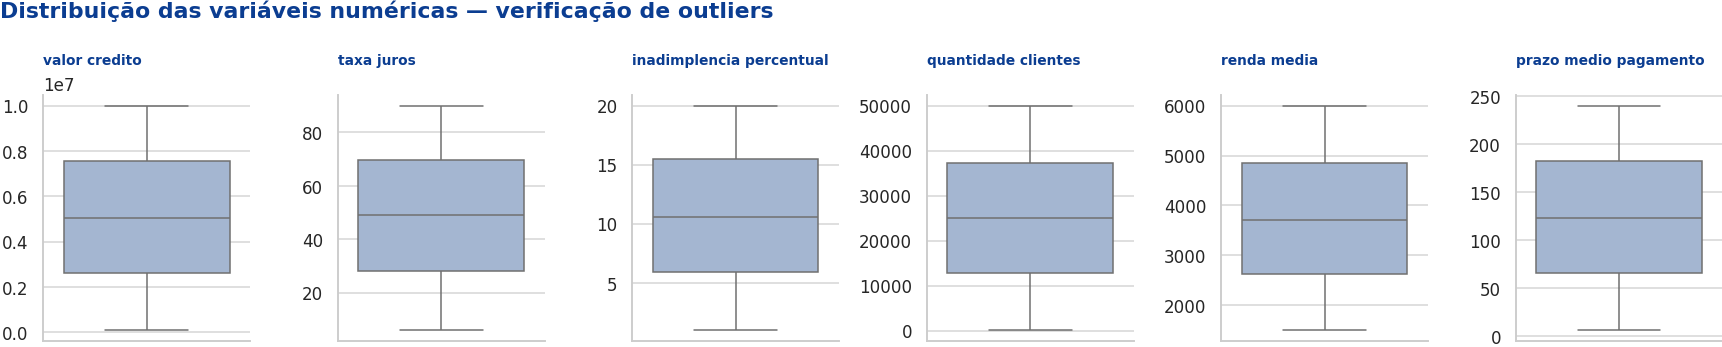

In [ ]:
# 5. Outliers (IQR) nas variáveis numéricas
def contar_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int((~serie.between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)).sum())

outliers = pd.Series({c: contar_outliers(df[c]) for c in numericas}, name="outliers (IQR)")
print(outliers.to_string())

fig, axes = plt.subplots(1, 6, figsize=(16, 3.4))
for ax, col in zip(axes, numericas):
    sns.boxplot(y=df[col], ax=ax, color="#9DB4D8", linewidth=1)
    ax.set_title(col.replace("_", " "), fontsize=9)
    ax.set_ylabel("")
fig.suptitle("Distribuição das variáveis numéricas — verificação de outliers", x=0.01, ha="left", color=AZUL, fontweight="bold")
plt.tight_layout()
plt.show()

**Resultado da limpeza:** a base não possui valores nulos, registros duplicados nem violações das regras de consistência,
e nenhuma variável numérica apresenta outliers pelo critério IQR — os valores estão distribuídos dentro de faixas
controladas, característica típica de dados simulados. Ainda assim, as rotinas foram mantidas (e também estão no
`app.py`) para garantir a robustez quando outra base for carregada via upload no dashboard.

## 6. Engenharia de atributos

Novas variáveis criadas para enriquecer a análise:

| Atributo | Cálculo | Uso |
|---|---|---|
| `periodo`, `trimestre`, `mes_nome` | derivados da data | análise temporal e sazonalidade |
| `valor_milhoes` | valor / 1.000.000 | legibilidade |
| `ticket_medio_cliente` | valor / clientes | perfil financeiro |
| `valor_em_atraso` | valor × inadimplência / 100 | risco financeiro em R$ |
| `faixa_juros`, `faixa_renda`, `faixa_prazo` | discretização | comparação entre grupos |
| `risco_alto` | 1 se risco = Alto | proporção de operações de alto risco |

In [ ]:
df["periodo"] = df["data"].dt.to_period("M").dt.to_timestamp()
df["trimestre"] = df["data"].dt.quarter
df["mes_nome"] = df["data"].dt.month.map({1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
                                         7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"})
df["valor_milhoes"] = df["valor_credito"] / 1e6
df["ticket_medio_cliente"] = df["valor_credito"] / df["quantidade_clientes"]
df["valor_em_atraso"] = df["valor_credito"] * df["inadimplencia_percentual"] / 100
df["faixa_juros"] = pd.cut(df["taxa_juros"], [0, 20, 40, 60, 80, np.inf],
                           labels=["Até 20%", "20–40%", "40–60%", "60–80%", "Acima de 80%"], include_lowest=True)
df["faixa_renda"] = pd.qcut(df["renda_media"], 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
df["faixa_prazo"] = pd.cut(df["prazo_medio_pagamento"], [0, 60, 120, 180, np.inf],
                           labels=["Até 60", "61–120", "121–180", "Acima de 180"], include_lowest=True)
df["risco_credito"] = pd.Categorical(df["risco_credito"], ["Baixo", "Médio", "Alto"], ordered=True)
df["risco_alto"] = (df["risco_credito"] == "Alto").astype(int)

df[["data", "uf", "modalidade_credito", "valor_milhoes", "ticket_medio_cliente", "valor_em_atraso",
    "faixa_juros", "faixa_renda", "faixa_prazo", "risco_alto"]].head()

,data,uf,modalidade_credito,valor_milhoes,ticket_medio_cliente,valor_em_atraso,faixa_juros,faixa_renda,faixa_prazo,risco_alto
0,2015-01-01,AM,Cartão,0.37,53.29,"28,701.44",Acima de 80%,Q4 (maior),Acima de 180,1
1,2015-01-01,PA,Veículos,7.65,191.17,"902,440.11",40–60%,Q1 (menor),Acima de 180,1
2,2015-01-01,PA,Veículos,7.80,318.61,"1,485,714.36",20–40%,Q2,Acima de 180,0
3,2015-01-01,RO,Cartão,8.11,782.49,"834,815.67",40–60%,Q4 (maior),Até 60,1
4,2015-01-01,TO,Imobiliário,9.06,192.01,"1,082,152.30",40–60%,Q2,121–180,1


## 7. Análise exploratória

In [ ]:
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
valor_credito,"4,440.00","5,055,122.34","2,855,877.36","103,030.85","2,616,980.84","5,055,087.10","7,551,529.52","9,998,738.88"
taxa_juros,"4,440.00",48.74,24.11,6.05,28.27,49.13,69.53,89.99
inadimplencia_percentual,"4,440.00",10.62,5.48,1.00,5.95,10.57,15.51,20.00
quantidade_clientes,"4,440.00","24,948.50","14,225.36",110.00,"12,810.50","24,983.50","37,236.25","49,984.00"
renda_media,"4,440.00","3,742.83","1,301.39","1,500.06","2,623.90","3,716.06","4,861.49","5,998.86"
prazo_medio_pagamento,"4,440.00",123.01,67.81,6.10,65.78,123.45,182.12,240.00


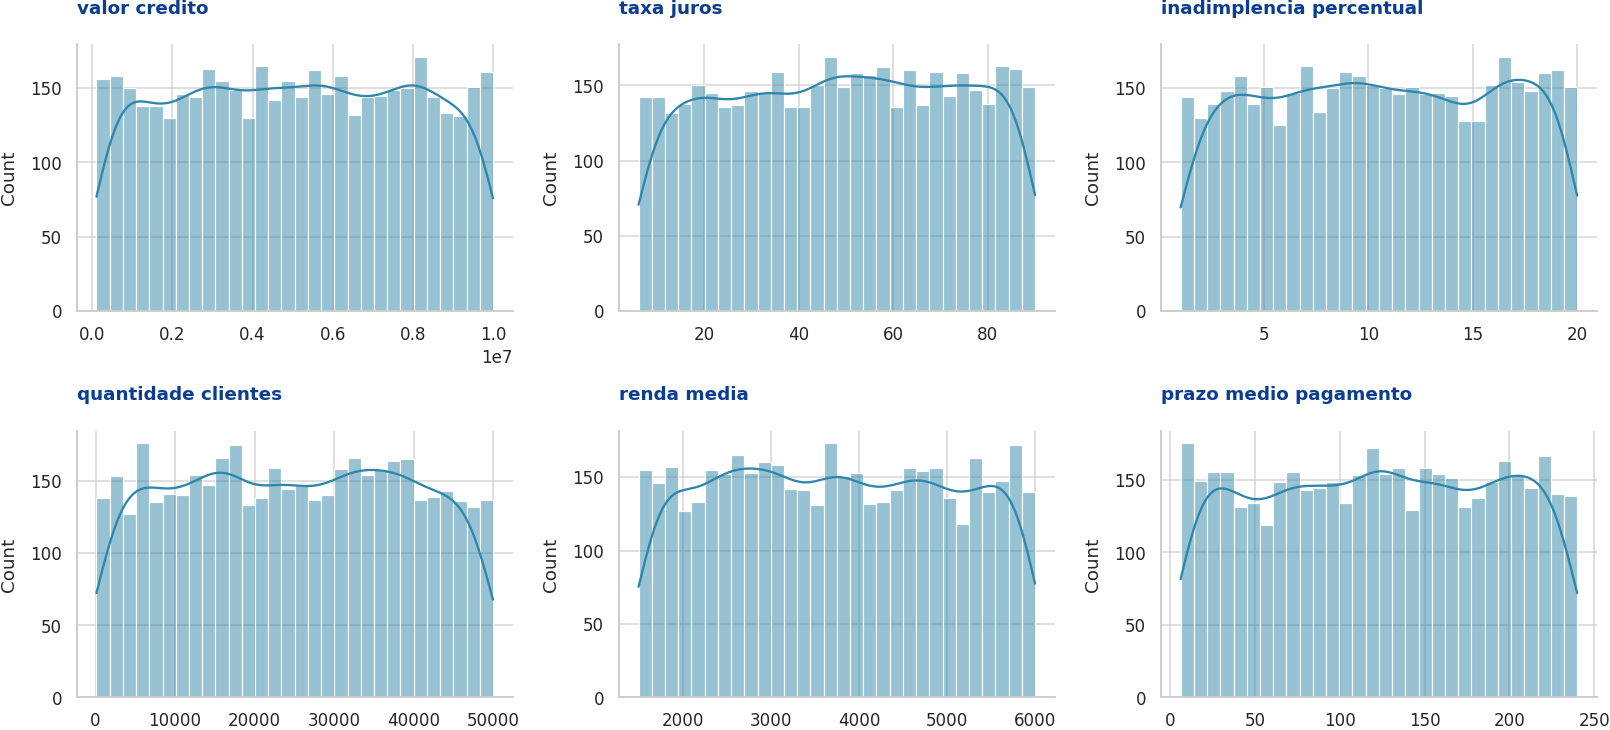

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, numericas):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#2E86AB")
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [ ]:
categoricas = ["regiao", "uf", "modalidade_credito", "risco_credito", "setor_economico"]
resumo = pd.DataFrame({
    "categorias": [df[c].nunique() for c in categoricas],
    "mais frequente": [df[c].value_counts().idxmax() for c in categoricas],
    "frequência": [df[c].value_counts().max() for c in categoricas],
}, index=categoricas)
resumo

,categorias,mais frequente,frequência
regiao,5,Sudeste,1560
uf,20,RJ,480
modalidade_credito,5,Imobiliário,912
risco_credito,3,Baixo,1501
setor_economico,4,Agropecuária,1132


In [ ]:
operacoes = df.groupby(["regiao", "uf"]).size().rename("registros").reset_index()
operacoes.pivot_table(index="regiao", values=["uf", "registros"], aggfunc={"uf": "nunique", "registros": "sum"}) \
         .rename(columns={"uf": "estados"}).sort_values("registros", ascending=False)

,registros,estados
regiao,,
Sudeste,1560,4
Nordeste,960,5
Sul,720,3
Centro-Oeste,600,4
Norte,600,4


**Observações iniciais**
- As variáveis numéricas têm distribuição aproximadamente **uniforme** (histogramas planos), sem assimetria relevante.
- As categorias de modalidade, risco e setor estão **balanceadas**.
- O número de registros **varia por região e estado**: o Sudeste possui mais estados e o RJ tem quatro registros por mês.
  Isso influencia diretamente os totais de volume e deve ser considerado na interpretação da concentração.

## 8. KPIs

In [ ]:
def br(v, casas=2):
    return f"{v:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

por_modalidade = df.groupby("modalidade_credito")["valor_credito"].sum()
por_regiao = df.groupby("regiao")["valor_credito"].sum()

kpis = pd.DataFrame({
    "KPI": ["Volume total de crédito", "Taxa média de juros", "Índice médio de inadimplência",
            "Modalidade mais utilizada (volume)", "Região com maior crédito", "Prazo médio de pagamento",
            "Clientes atendidos", "Valor estimado em atraso", "Ticket médio por cliente", "Operações de risco alto"],
    "Valor": [f"R$ {br(df['valor_credito'].sum() / 1e9)} bilhões", f"{br(df['taxa_juros'].mean())}% a.a.",
              f"{br(df['inadimplencia_percentual'].mean())}%",
              f"{por_modalidade.idxmax()} ({br(por_modalidade.max() / por_modalidade.sum() * 100, 1)}%)",
              f"{por_regiao.idxmax()} ({br(por_regiao.max() / por_regiao.sum() * 100, 1)}%)",
              f"{br(df['prazo_medio_pagamento'].mean(), 1)} meses", br(df["quantidade_clientes"].sum(), 0),
              f"R$ {br(df['valor_em_atraso'].sum() / 1e9)} bilhões",
              f"R$ {br(df['valor_credito'].sum() / df['quantidade_clientes'].sum())}",
              f"{br(df['risco_alto'].mean() * 100, 1)}%"],
    "Categoria": ["Financeiro", "Econômico", "Risco", "Ranking", "Regional", "Perfil",
                  "Alcance", "Risco", "Perfil", "Risco"],
})
kpis

,KPI,Valor,Categoria
0,Volume total de crédito,"R$ 22,44 bilhões",Financeiro
1,Taxa média de juros,"48,74% a.a.",Econômico
2,Índice médio de inadimplência,"10,62%",Risco
3,Modalidade mais utilizada (volume),"Cartão (20,5%)",Ranking
4,Região com maior crédito,"Sudeste (36,3%)",Regional
5,Prazo médio de pagamento,"123,0 meses",Perfil
6,Clientes atendidos,110.771.328,Alcance
7,Valor estimado em atraso,"R$ 2,38 bilhões",Risco
8,Ticket médio por cliente,"R$ 202,62",Perfil
9,Operações de risco alto,"32,8%",Risco


## 9. Gráficos e análises

### 9.1 Evolução temporal do crédito

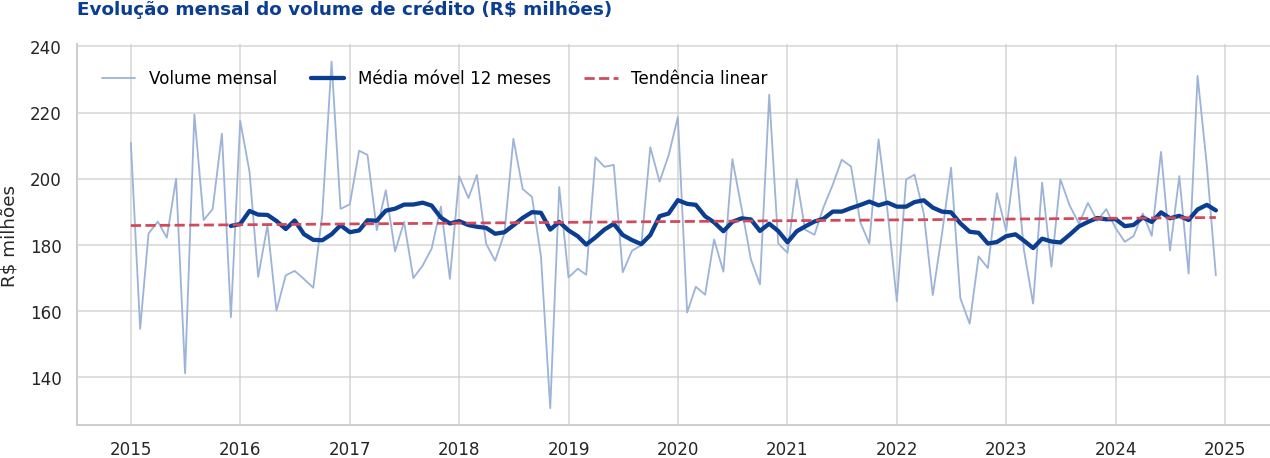

Inclinação da tendência: 0,25 milhões por ano


In [ ]:
mensal = df.groupby("periodo").agg(volume=("valor_credito", "sum"), juros=("taxa_juros", "mean"),
                                   inad=("inadimplencia_percentual", "mean")).reset_index()
mensal["mm12"] = mensal["volume"].rolling(12).mean()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(mensal["periodo"], mensal["volume"] / 1e6, color="#9DB4D8", lw=1.2, label="Volume mensal")
ax.plot(mensal["periodo"], mensal["mm12"] / 1e6, color=AZUL, lw=2.8, label="Média móvel 12 meses")
coef = np.polyfit(np.arange(len(mensal)), mensal["volume"] / 1e6, 1)
ax.plot(mensal["periodo"], np.polyval(coef, np.arange(len(mensal))), "--", color="#D1495B", lw=1.8, label="Tendência linear")
ax.set_title("Evolução mensal do volume de crédito (R$ milhões)")
ax.set_ylabel("R$ milhões")
ax.legend(ncol=3, frameon=False, loc="upper left")
salvar(fig, "01_evolucao_temporal.png")
plt.show()
print(f"Inclinação da tendência: {br(coef[0] * 12)} milhões por ano")

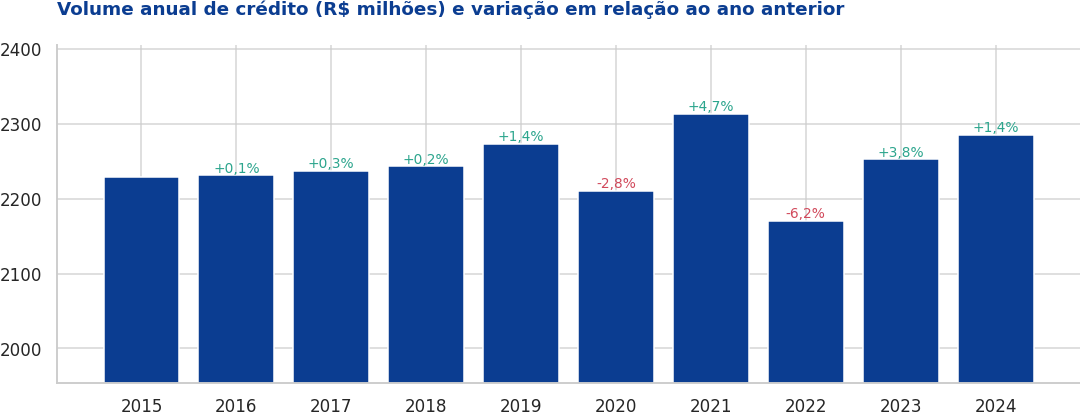

CAGR 2015–2024: 0,28% ao ano


,volume,juros,inadimplencia,clientes,variacao_volume_%
ano,,,,,
2015,"2,228.63",49.71,10.85,10756636,NaN
2016,"2,231.07",48.00,10.51,11058605,0.11
2017,"2,237.50",48.05,10.93,10921484,0.29
2018,"2,243.05",49.98,10.77,10762445,0.25
2019,"2,273.50",50.11,10.62,11153195,1.36
2020,"2,210.15",47.75,10.34,11530579,-2.79
2021,"2,313.16",48.45,10.17,11070008,4.66
2022,"2,170.09",47.76,10.63,11365644,-6.19
2023,"2,252.59",49.49,10.97,11590524,3.80


In [ ]:
anual = df.groupby("ano").agg(volume=("valor_credito", "sum"), juros=("taxa_juros", "mean"),
                              inadimplencia=("inadimplencia_percentual", "mean"),
                              clientes=("quantidade_clientes", "sum"))
anual["variacao_volume_%"] = anual["volume"].pct_change() * 100
anual["volume"] = anual["volume"] / 1e6
cagr = ((anual["volume"].iloc[-1] / anual["volume"].iloc[0]) ** (1 / (len(anual) - 1)) - 1) * 100

fig, ax = plt.subplots(figsize=(12, 4))
barras = ax.bar(anual.index.astype(str), anual["volume"], color=AZUL)
for barra, var in zip(barras, anual["variacao_volume_%"]):
    if pd.notna(var):
        ax.annotate(f"{var:+.1f}%".replace(".", ","), (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    ha="center", va="bottom", fontsize=9, color="#D1495B" if var < 0 else "#2CA58D")
ax.set_ylim(anual["volume"].min() * 0.9, anual["volume"].max() * 1.04)
ax.set_title("Volume anual de crédito (R$ milhões) e variação em relação ao ano anterior")
salvar(fig, "02_volume_anual.png")
plt.show()
print(f"CAGR 2015–2024: {br(cagr)}% ao ano")
anual.round(2)

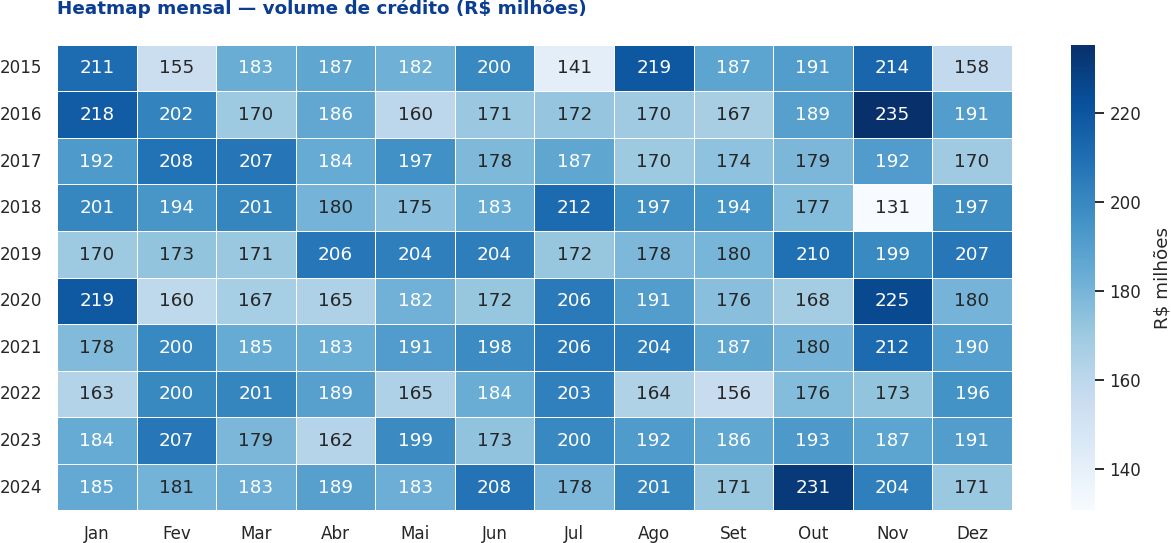

In [ ]:
heat = df.pivot_table(index="ano", columns="mes", values="valor_credito", aggfunc="sum") / 1e6
heat.columns = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
fig, ax = plt.subplots(figsize=(14, 5.5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5, cbar_kws={"label": "R$ milhões"}, ax=ax)
ax.set_title("Heatmap mensal — volume de crédito (R$ milhões)")
ax.tick_params(axis="y", rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
salvar(fig, "03_heatmap_mensal.png")
plt.show()

### 9.2 Comparação entre regiões e concentração por estado

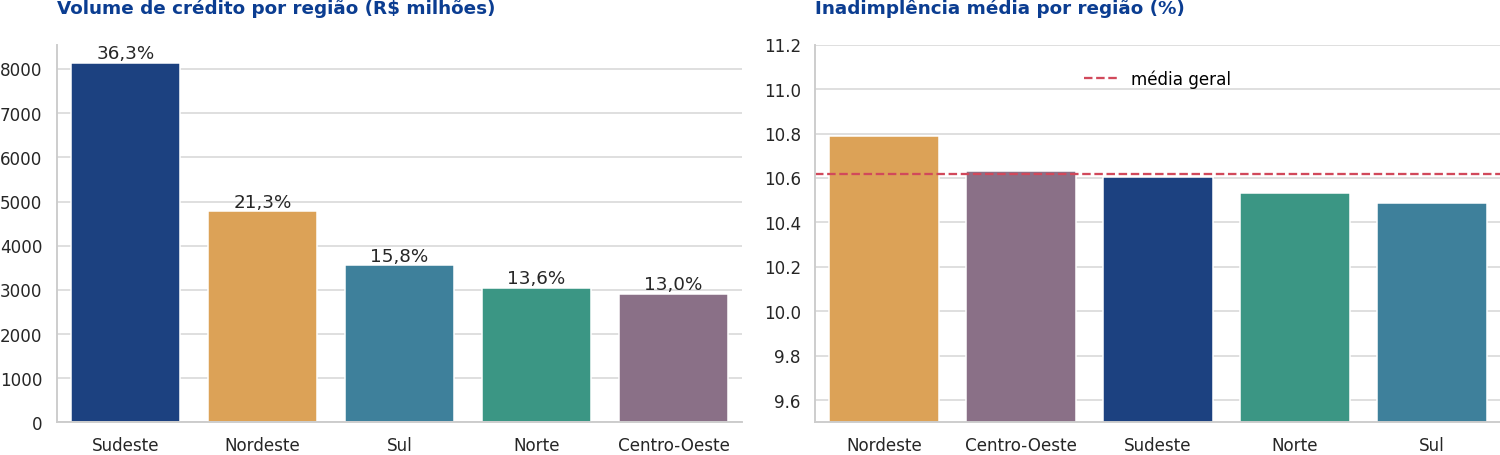

,volume,inadimplencia,juros,registros,renda,participacao_%,volume_por_registro_mi
regiao,,,,,,,
Sudeste,"8,143.14",10.60,49.23,1560,"3,707.11",36.28,5.22
Nordeste,"4,783.55",10.79,47.58,960,"3,825.37",21.31,4.98
Sul,"3,557.17",10.49,48.53,720,"3,681.63",15.85,4.94
Norte,"3,046.92",10.53,48.46,600,"3,713.51",13.58,5.08
Centro-Oeste,"2,913.96",10.63,49.82,600,"3,806.43",12.98,4.86


In [ ]:
regiao = df.groupby("regiao").agg(volume=("valor_credito", "sum"), inadimplencia=("inadimplencia_percentual", "mean"),
                                  juros=("taxa_juros", "mean"), registros=("uf", "size"),
                                  renda=("renda_media", "mean")).sort_values("volume", ascending=False)
regiao["participacao_%"] = regiao["volume"] / regiao["volume"].sum() * 100
regiao["volume_por_registro_mi"] = regiao["volume"] / regiao["registros"] / 1e6
regiao["volume"] = regiao["volume"] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=regiao.index, y=regiao["volume"], hue=regiao.index, palette=CORES_REGIAO, ax=axes[0], legend=False)
for i, v in enumerate(regiao["participacao_%"]):
    axes[0].text(i, regiao["volume"].iloc[i], f"{br(v, 1)}%", ha="center", va="bottom")
axes[0].set_title("Volume de crédito por região (R$ milhões)")
axes[0].set_xlabel(""); axes[0].set_ylabel("")
ordem = regiao.sort_values("inadimplencia", ascending=False)
sns.barplot(x=ordem.index, y=ordem["inadimplencia"], hue=ordem.index, palette=CORES_REGIAO, ax=axes[1], legend=False)
axes[1].axhline(df["inadimplencia_percentual"].mean(), ls="--", color="#D1495B", label="média geral")
axes[1].set_ylim(9.5, 11.2)
axes[1].set_title("Inadimplência média por região (%)")
axes[1].set_xlabel(""); axes[1].set_ylabel("")
axes[1].legend(frameon=False)
plt.tight_layout()
salvar(fig, "04_regioes.png")
plt.show()
regiao.round(2)

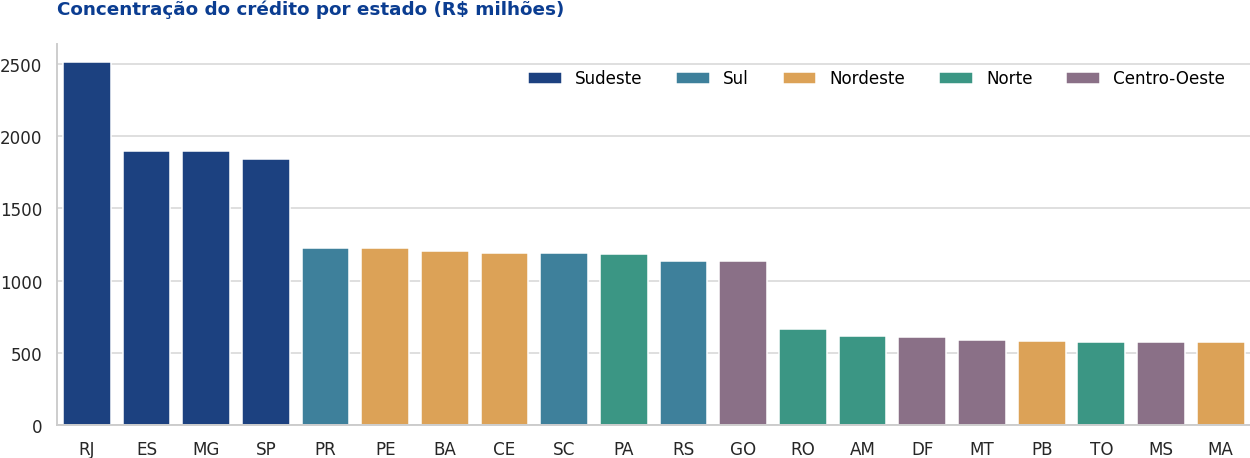

Índice HHI: 617 (abaixo de 1.500 = baixa concentração) | CR3 (3 maiores estados): 28,1%


,uf,regiao,volume,inadimplencia,participacao_%
14,RJ,Sudeste,"2,508,961,731.74",10.85,11.18
4,ES,Sudeste,"1,898,078,614.68",10.55,8.46
7,MG,Sudeste,"1,894,081,644.74",10.15,8.44
18,SP,Sudeste,"1,842,020,383.57",10.78,8.21
13,PR,Sul,"1,230,151,025.61",10.79,5.48


In [ ]:
uf = df.groupby(["uf", "regiao"]).agg(volume=("valor_credito", "sum"),
                                      inadimplencia=("inadimplencia_percentual", "mean")).reset_index()
uf["participacao_%"] = uf["volume"] / uf["volume"].sum() * 100
uf = uf.sort_values("volume", ascending=False)
hhi = (uf["participacao_%"] ** 2).sum()
cr3 = uf["participacao_%"].head(3).sum()

fig, ax = plt.subplots(figsize=(14, 4.5))
sns.barplot(data=uf, x="uf", y=uf["volume"] / 1e6, hue="regiao", palette=CORES_REGIAO, dodge=False, ax=ax)
ax.set_title("Concentração do crédito por estado (R$ milhões)")
ax.set_xlabel(""); ax.set_ylabel("")
ax.legend(title="", ncol=5, frameon=False, loc="upper right")
salvar(fig, "05_concentracao_uf.png")
plt.show()
print(f"Índice HHI: {br(hhi, 0)} (abaixo de 1.500 = baixa concentração) | CR3 (3 maiores estados): {br(cr3, 1)}%")
uf.head(5).round(2)

### 9.3 Comparação entre modalidades e evolução do risco de crédito

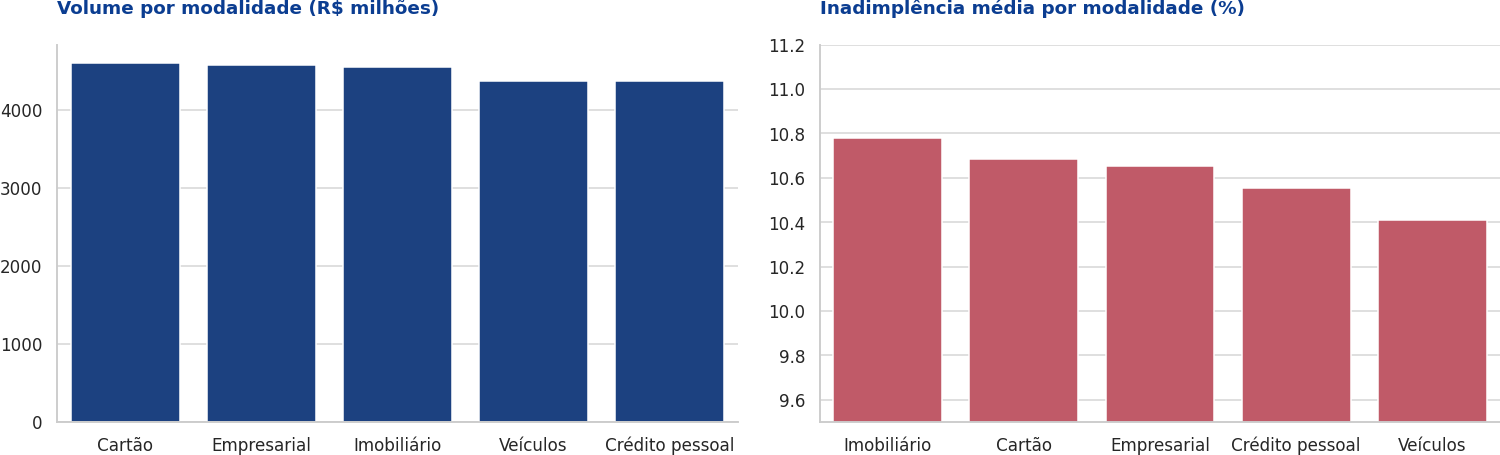

,volume,clientes,inadimplencia,juros,risco_alto_pct
modalidade_credito,,,,,
Cartão,"4,600.97",22372750,10.68,49.70,32.34
Empresarial,"4,566.48",22968212,10.65,48.17,33.08
Imobiliário,"4,540.50",23445152,10.78,48.33,32.57
Veículos,"4,368.46",21319201,10.41,49.38,34.95
Crédito pessoal,"4,368.32",20666013,10.55,48.08,31.12


In [ ]:
modalidade = df.groupby("modalidade_credito").agg(
    volume=("valor_credito", "sum"), clientes=("quantidade_clientes", "sum"),
    inadimplencia=("inadimplencia_percentual", "mean"), juros=("taxa_juros", "mean"),
    risco_alto_pct=("risco_alto", "mean")).sort_values("volume", ascending=False)
modalidade["risco_alto_pct"] *= 100
modalidade["volume"] /= 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=modalidade.index, y=modalidade["volume"], color=AZUL, ax=axes[0])
axes[0].set_title("Volume por modalidade (R$ milhões)")
axes[0].set_xlabel(""); axes[0].set_ylabel("")
ordem = modalidade.sort_values("inadimplencia", ascending=False)
sns.barplot(x=ordem.index, y=ordem["inadimplencia"], color="#D1495B", ax=axes[1])
axes[1].set_ylim(9.5, 11.2)
axes[1].set_title("Inadimplência média por modalidade (%)")
axes[1].set_xlabel(""); axes[1].set_ylabel("")
plt.tight_layout()
salvar(fig, "06_modalidades.png")
plt.show()
modalidade.round(2)

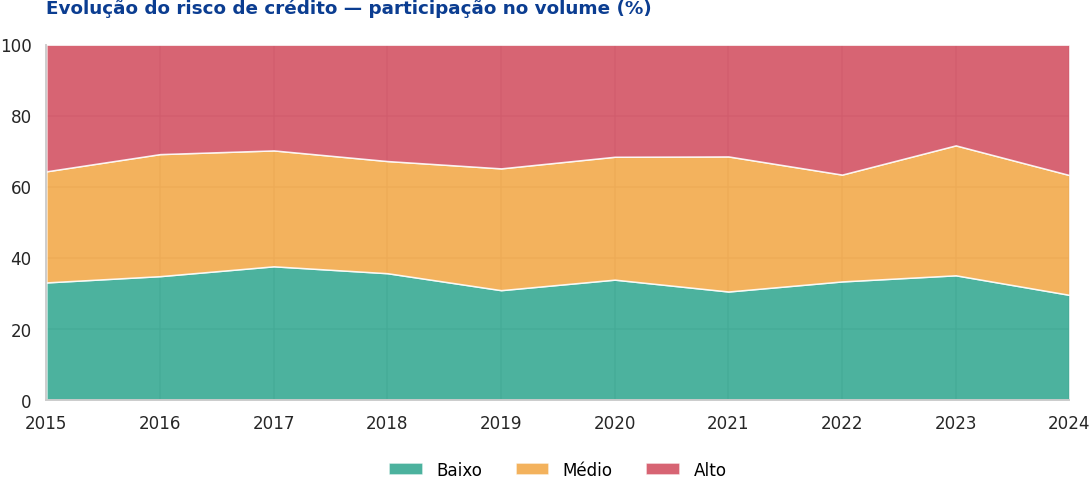

risco_credito,Baixo,Médio,Alto
ano,,,
2015,33.20,31.20,35.60
2016,34.90,34.30,30.80
2017,37.70,32.60,29.70
2018,35.80,31.50,32.70
2019,31.00,34.20,34.80
2020,34.00,34.50,31.50
2021,30.60,38.00,31.40
2022,33.50,30.00,36.50
2023,35.20,36.50,28.30


In [ ]:
risco_ano = df.pivot_table(index="ano", columns="risco_credito", values="valor_credito", aggfunc="sum", observed=True)
risco_ano = risco_ano.div(risco_ano.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.stackplot(risco_ano.index, risco_ano.T, labels=risco_ano.columns,
             colors=[CORES_RISCO[c] for c in risco_ano.columns], alpha=0.85)
ax.set_title("Evolução do risco de crédito — participação no volume (%)")
ax.set_xlim(risco_ano.index.min(), risco_ano.index.max())
ax.set_ylim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
salvar(fig, "07_evolucao_risco.png")
plt.show()
risco_ano.round(1)

### 9.4 Análise por setor econômico

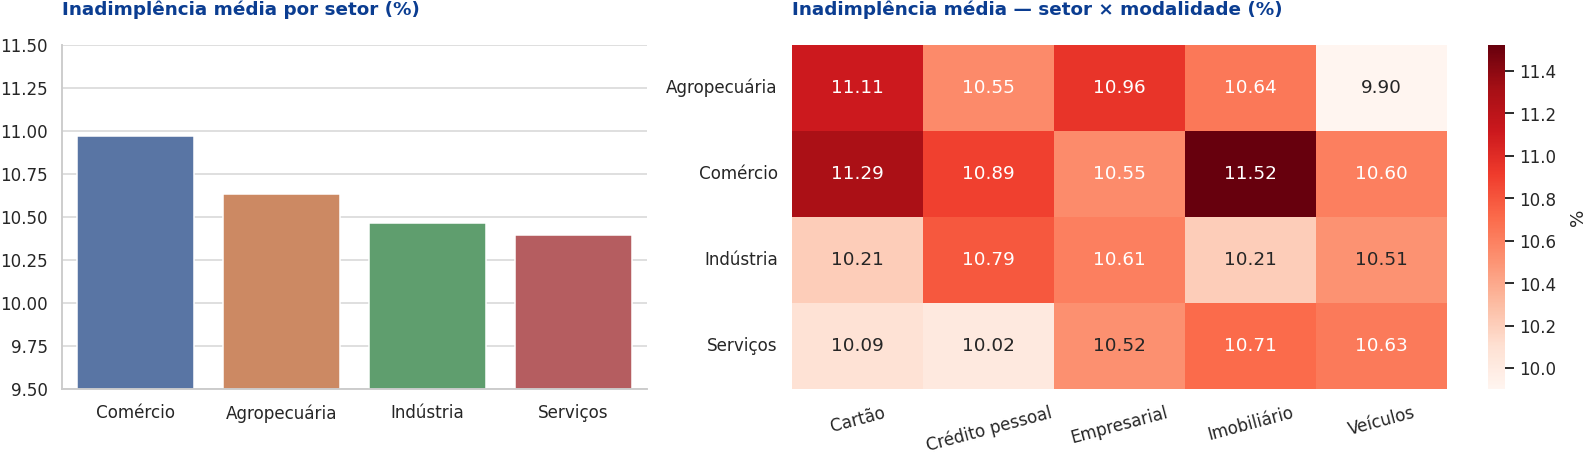

,inadimplencia,valor_em_atraso_mi,juros
setor_economico,,,
Comércio,10.97,591.37,48.64
Agropecuária,10.63,607.87,49.56
Indústria,10.47,589.43,47.20
Serviços,10.40,588.56,49.51


In [ ]:
setor = df.groupby("setor_economico").agg(inadimplencia=("inadimplencia_percentual", "mean"),
                                          valor_em_atraso_mi=("valor_em_atraso", "sum"),
                                          juros=("taxa_juros", "mean")).sort_values("inadimplencia", ascending=False)
setor["valor_em_atraso_mi"] /= 1e6

matriz = df.pivot_table(index="setor_economico", columns="modalidade_credito",
                        values="inadimplencia_percentual", aggfunc="mean")
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})
sns.barplot(x=setor.index, y=setor["inadimplencia"], hue=setor.index, palette="deep", ax=axes[0], legend=False)
axes[0].set_ylim(9.5, 11.5)
axes[0].set_title("Inadimplência média por setor (%)")
axes[0].set_xlabel(""); axes[0].set_ylabel("")
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="Reds", ax=axes[1], cbar_kws={"label": "%"})
axes[1].set_title("Inadimplência média — setor × modalidade (%)")
axes[1].tick_params(axis="y", rotation=0)
axes[1].tick_params(axis="x", rotation=15)
axes[1].set_xlabel(""); axes[1].set_ylabel("")
plt.tight_layout()
salvar(fig, "08_setores.png")
plt.show()
setor.round(2)

### 9.5 Relação entre juros e inadimplência (correlação estatística)

Pearson  r = -0.0082 (p-valor = 0.5857)
Spearman ρ = -0.0081 (p-valor = 0.5886)
R² = 0.00007


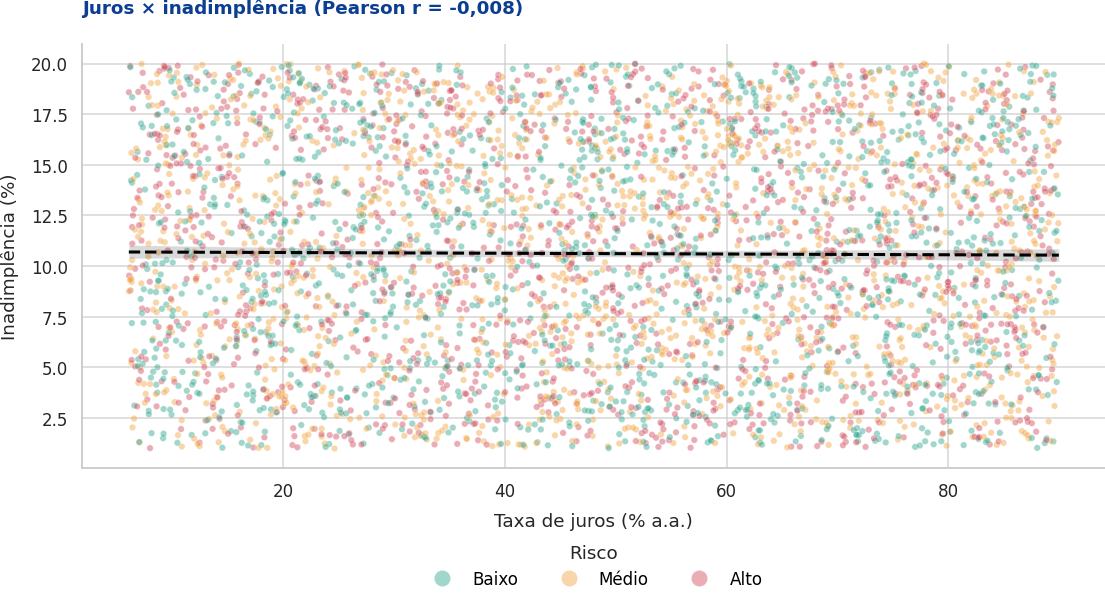

In [ ]:
r, p_r = stats.pearsonr(df["taxa_juros"], df["inadimplencia_percentual"])
rho, p_rho = stats.spearmanr(df["taxa_juros"], df["inadimplencia_percentual"])
print(f"Pearson  r = {r:.4f} (p-valor = {p_r:.4f})")
print(f"Spearman ρ = {rho:.4f} (p-valor = {p_rho:.4f})")
print(f"R² = {r**2:.5f}")

fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(data=df, x="taxa_juros", y="inadimplencia_percentual", hue="risco_credito",
                palette=CORES_RISCO, alpha=0.45, s=18, ax=ax)
sns.regplot(data=df, x="taxa_juros", y="inadimplencia_percentual", scatter=False, ax=ax,
            line_kws={"color": "black", "lw": 2, "ls": "--"})
ax.set_title(f"Juros × inadimplência (Pearson r = {r:.3f})".replace(".", ","))
ax.set_xlabel("Taxa de juros (% a.a.)")
ax.set_ylabel("Inadimplência (%)")
ax.legend(title="Risco", frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), markerscale=2.5)
salvar(fig, "09_juros_inadimplencia.png")
plt.show()

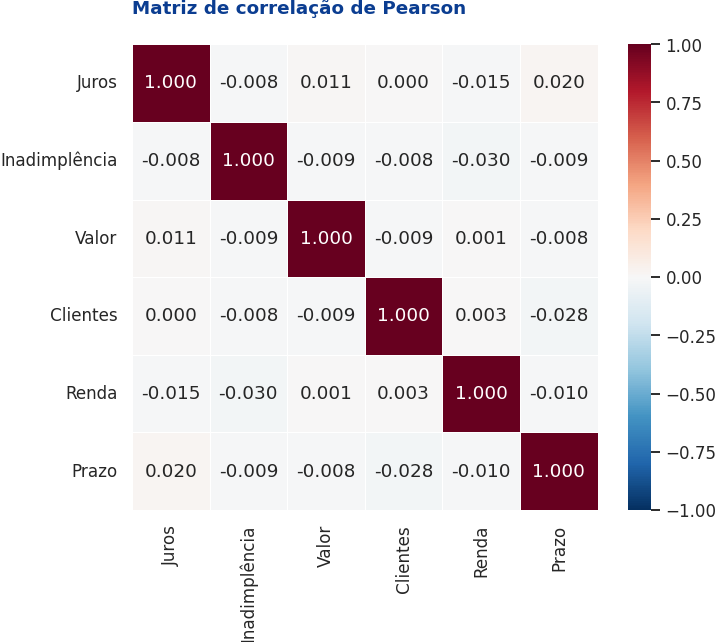

,inadimplencia_media,operacoes
faixa_juros,,
Até 20%,10.66,701
20–40%,10.77,1021
40–60%,10.39,1098
60–80%,10.72,1077
Acima de 80%,10.57,543


In [ ]:
faixa = df.groupby("faixa_juros", observed=True)["inadimplencia_percentual"].agg(["mean", "count"])
faixa.columns = ["inadimplencia_media", "operacoes"]

variaveis = {"taxa_juros": "Juros", "inadimplencia_percentual": "Inadimplência", "valor_credito": "Valor",
             "quantidade_clientes": "Clientes", "renda_media": "Renda", "prazo_medio_pagamento": "Prazo"}
corr = df[list(variaveis)].rename(columns=variaveis).corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlação de Pearson")
salvar(fig, "10_matriz_correlacao.png")
plt.show()
faixa.round(2)

### 9.6 Identificação de regiões e estados críticos

Critério: escore médio dos *z-scores* de inadimplência, juros e proporção de operações de risco alto.
Estados com escore > 0,5 são classificados como **críticos**.

In [ ]:
crit = df.groupby(["uf", "regiao"]).agg(inadimplencia=("inadimplencia_percentual", "mean"),
                                        juros=("taxa_juros", "mean"), risco_alto=("risco_alto", "mean"),
                                        valor_em_atraso_mi=("valor_em_atraso", "sum")).reset_index()
crit["valor_em_atraso_mi"] /= 1e6
crit["risco_alto"] *= 100
for c in ["inadimplencia", "juros", "risco_alto"]:
    crit[f"z_{c}"] = (crit[c] - crit[c].mean()) / crit[c].std(ddof=0)
crit["escore"] = crit[["z_inadimplencia", "z_juros", "z_risco_alto"]].mean(axis=1)
crit["situacao"] = np.select([crit["escore"] > 0.5, crit["escore"] > 0], ["Crítico", "Atenção"], "Adequado")
crit.sort_values("escore", ascending=False)[["uf", "regiao", "inadimplencia", "juros", "risco_alto",
                                             "valor_em_atraso_mi", "escore", "situacao"]].head(8).round(2)

,uf,regiao,inadimplencia,juros,risco_alto,valor_em_atraso_mi,escore,situacao
13,PR,Sul,10.79,48.93,36.25,136.55,0.63,Crítico
2,CE,Nordeste,11.26,47.80,34.17,133.15,0.53,Crítico
4,ES,Sudeste,10.55,49.61,35.56,200.05,0.51,Crítico
5,GO,Centro-Oeste,10.58,50.82,32.50,117.00,0.49,Atenção
8,MS,Centro-Oeste,11.17,49.56,30.00,65.70,0.41,Atenção
0,AM,Norte,11.31,50.13,27.50,69.66,0.39,Atenção
3,DF,Centro-Oeste,10.53,47.29,39.17,62.09,0.32,Atenção
14,RJ,Sudeste,10.85,49.68,31.04,267.16,0.27,Atenção


## 10. Persistência em banco

A base é armazenada em um banco SQLite com **modelagem relacional** (esquema estrela): tabelas dimensão
(`dim_regiao`, `dim_uf`, `dim_modalidade`, `dim_setor`, `dim_risco`), a tabela fato `fato_credito` e a view
`vw_credito_completo`. O código está em `database/banco.py` e é reutilizado pelo dashboard.

In [ ]:
from database.banco import CONSULTAS, consultar, criar_banco, get_engine, listar_tabelas

caminho = criar_banco(df_bruto)
print("Banco:", caminho.relative_to(RAIZ))
print("Objetos:", ", ".join(listar_tabelas(get_engine())))
consultar(CONSULTAS["Ranking de estados (concentração do crédito)"]).head(6)

Banco: database/sistema_financeiro.db
Objetos: dim_modalidade, dim_regiao, dim_risco, dim_setor, dim_uf, fato_credito, vw_credito_completo


,uf,regiao,volume_milhoes,participacao_pct
0,RJ,Sudeste,"2,508.96",11.18
1,ES,Sudeste,"1,898.08",8.46
2,MG,Sudeste,"1,894.08",8.44
3,SP,Sudeste,"1,842.02",8.21
4,PR,Sul,"1,230.15",5.48
5,PE,Nordeste,"1,228.60",5.47


In [ ]:
consultar(CONSULTAS["Risco por modalidade"])

,modalidade,inadimplencia_media,juros_medio,pct_risco_alto
0,Imobiliário,10.78,48.33,32.60
1,Cartão,10.68,49.70,32.30
2,Empresarial,10.65,48.17,33.10
3,Crédito pessoal,10.55,48.08,31.10
4,Veículos,10.41,49.38,35.00


## 11. Interpretação dos resultados

**1. Regiões com maior volume de crédito.** O **Sudeste** concentra cerca de **36%** do volume (≈ R$ 8,1 bilhões),
seguido do Nordeste (≈ 21%). Essa liderança é explicada principalmente pelo **número de registros**: o Sudeste reúne
quatro estados e o RJ possui quatro operações por mês. O valor médio por registro é muito semelhante entre as regiões
(entre R$ 4,9 e R$ 5,2 milhões), ou seja, não há diferença estrutural de porte das operações.

**2. Setores com maior inadimplência.** **Comércio** apresenta a maior inadimplência média (≈ 10,97%), e **Serviços** a
menor (≈ 10,40%). A diferença de ~0,6 p.p. é pequena; em valor, porém, a Agropecuária acumula o maior montante em atraso
por concentrar mais volume.

**3. Crescimento do crédito.** O volume anual permaneceu **estável** (≈ R$ 2,2–2,3 bilhões/ano), com CAGR próximo de
**0,3% ao ano**. Destacam-se a queda em 2020 (-2,8%), o pico em 2021 e o recuo em 2022 — oscilações sem tendência
estrutural de expansão.

**4. Juros × inadimplência.** A correlação de Pearson é **≈ -0,008** (p-valor ≈ 0,59) e a de Spearman é equivalente:
**não há relação estatisticamente significativa** entre juros e inadimplência nesta base. O R² é praticamente zero.
Na prática, isso indica que a taxa cobrada **não está precificando o risco** — um ponto de atenção em uma carteira real.

**5. Modalidades de maior risco.** **Imobiliário** tem a maior inadimplência média (≈ 10,78%) e **Veículos** a maior
proporção de operações classificadas como risco alto (≈ 35%). A amplitude entre modalidades é inferior a 0,4 p.p.,
indicando risco relativamente homogêneo entre produtos.

**6. Evolução do comportamento financeiro.** Juros médios oscilaram entre ≈ 47,8% e 50,1% a.a. e a inadimplência entre
≈ 10,2% e 11,0%. A participação do risco alto no volume variou entre 28% e 37% ao longo dos anos, sem tendência definida.

**7. Concentração bancária.** **RJ** lidera com ≈ 11,2% do crédito; RJ, ES e MG somam ≈ 28%. O **HHI ≈ 617** indica
**baixa concentração** (limite usual: 1.500). Os estados com pior combinação de inadimplência, juros e risco alto
(**PR, CE e ES**) foram classificados como críticos.

## 12. Conclusão

A análise mostrou um sistema de crédito **estável e pouco concentrado**, em que o volume é liderado pelo Sudeste (com
destaque para o RJ) principalmente pela quantidade de operações, e não pelo porte delas. Os indicadores de risco
são **homogêneos** entre regiões, setores e modalidades, e a **ausência de correlação entre juros e inadimplência**
sugere que o preço do crédito não reflete o risco efetivamente observado.

**Recomendações**
1. Priorizar monitoramento dos estados classificados como críticos (PR, CE, ES) e do setor de Comércio;
2. Revisar modelos de precificação, incorporando variáveis de perfil do tomador e garantias;
3. Diversificar a carteira entre modalidades, reduzindo exposição a produtos com maior proporção de risco alto (Veículos);
4. Acompanhar indicadores macroeconômicos reais (Selic e inadimplência do SFN — integrados ao dashboard via API do BCB).

**Limitações.** A base é **simulada**, com distribuições praticamente uniformes; por isso as diferenças entre grupos
são pequenas e as correlações próximas de zero. O método desenvolvido (tratamento, KPIs, visualizações, banco relacional
e dashboard) pode ser aplicado diretamente a dados reais, como o SCR e as estatísticas de crédito do Banco Central.